Approach:
- explore rating distributions
     - plot rating distributions
     - look at review text
     - check out metadata

- split training into train vs. validation
    - like hold user's last interactions from `train.csv` for validation

- what makes a good user profile?
    - user who loves puzzles will have review mentioning puzzle, brain teaser, etc
    

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [10]:
metadata = pd.read_csv("item_metadata.csv")
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [11]:
metadata

,item_id,title,description,features,categories,main_category,store,price,average_rating
0,i_5165,Mahjong 2015,Mahjong 2015 is a free solitaire matching game...,Mahjong 2015 is a free solitaire matching game...,NaN,Appstore for Android,sophiathach,0.00,3.1
1,i_7178,RoverCraft Race Your Space Car,Play The World Famous Car Crafting Runner with...,14 different planets from the galaxy to race o...,NaN,Appstore for Android,Mobirate,0.00,3.9
2,i_4289,Just Escape,"Just Escape, whether it's a medieval castle or...",Escape from rooms deep in a medieval castle or...,NaN,Appstore for Android,Inertia Game Studios,0.00,3.5
3,i_4772,TurboTax Deluxe 2014 Fed + State + Fed Efile T...,Tax Software that helps you get your taxes don...,This product is backed by Intuit’s 60 Day Mone...,"Software, Intuit, All Intuit",Software,Intuit,NaN,4.4
4,i_4232,How to Draw: Frozen,Frozen Characters drawing lessons are grouped ...,Free to use! Portable so you can learn to draw...,NaN,Appstore for Android,DrawMate,0.00,3.7
...,...,...,...,...,...,...,...,...,...
8676,i_2903,Office Suite,Office Suite is the best alternative to other ...,Includes a complete word processor to help wit...,"Software, Children's",Software,Encore,NaN,2.7
8677,i_0638,Corel Photo and Video Pro X4 Ultimate Bundle [...,Product Description With our best photo- and v...,Ultimate bundle combines powerful photo- and v...,"Software, Corel, All Corel",NaN,Corel,99.99,3.1
8678,i_3518,Corel WinZip 18 [Old Version],Unzip all major formats Protect your privacy V...,The world's #1 compression software Privacy pr...,"Software, Corel, All Corel",Software,Corel,NaN,3.2
8679,i_3096,Quicken Rental Property Manager 2014 [OLD VERS...,From the Manufacturer Intuit Quicken Rental Pr...,Organizes your personal and rental property fi...,"Software, Accounting & Finance, Personal Finan...",Software,Intuit,NaN,3.1


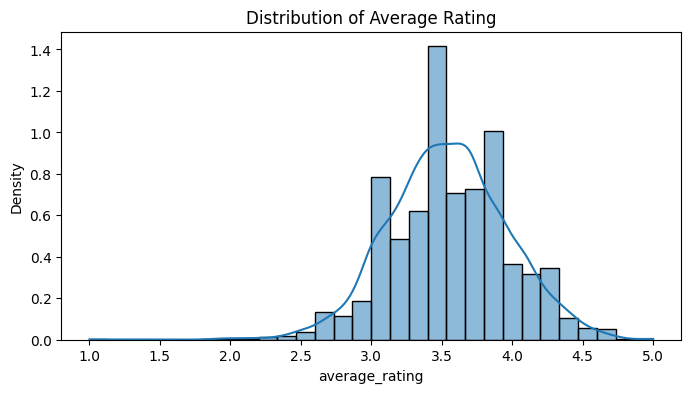

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(metadata["average_rating"], kde=True, stat="density", bins=30)
plt.xlabel("average_rating")
plt.ylabel("Density")
plt.title("Distribution of Average Rating")
plt.show()

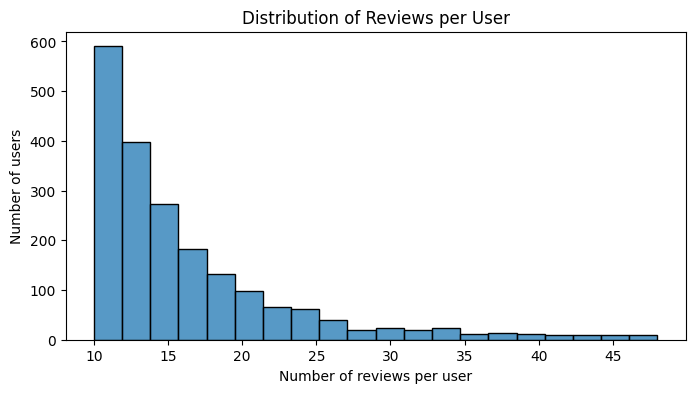

In [27]:
interactions_per_user = train.groupby("user_id").count()["rating"]

plt.figure(figsize=(8, 4))
sns.histplot(interactions_per_user, bins = 20)
plt.xlabel("Number of reviews per user")
plt.ylabel("Number of users")
plt.title("Distribution of Reviews per User")
plt.show()

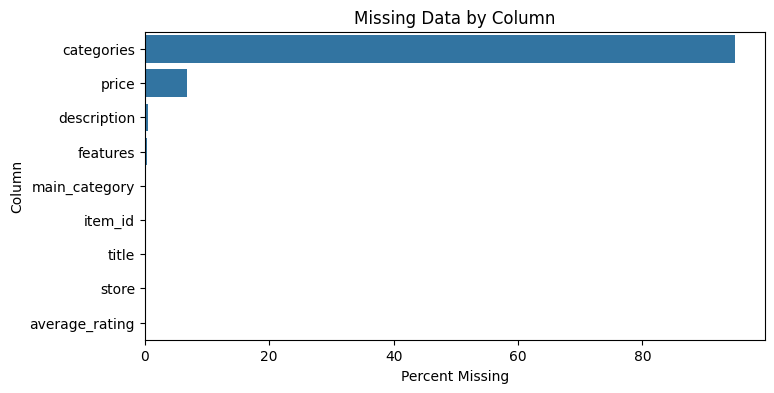

In [34]:
missing = (
    metadata.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)

plt.figure(figsize=(8, 4))
sns.barplot(data=missing, x="missing_pct", y="column")
plt.xlabel("Percent Missing")
plt.ylabel("Column")
plt.title("Missing Data by Column")
plt.show()


In [39]:
metadata["title"]

0                                            Mahjong 2015
1                          RoverCraft Race Your Space Car
2                                             Just Escape
3       TurboTax Deluxe 2014 Fed + State + Fed Efile T...
4                                     How to Draw: Frozen
                              ...                        
8676                                         Office Suite
8677    Corel Photo and Video Pro X4 Ultimate Bundle [...
8678                        Corel WinZip 18 [Old Version]
8679    Quicken Rental Property Manager 2014 [OLD VERS...
8680        Quicken Legal Business Pro 2011 [Old Version]
Name: title, Length: 8681, dtype: str